# RMT-PPAD migration NB80 - Phase P1 (BDD lane labels -> CLRHead 78-D)

**Purpose.** Convert BDD100K's native lane polyline annotations directly
to 78-D CLRHead target vectors. Each polyline becomes one row of a
`(4, 78)` tensor written to `lane_targets/{train2017,val2017}/<stem>.pt`.

**Source.** This project uses the original BDD100K v1 dataset. The lane
labels live inside `bdd100k_labels.zip` (already in your Drive at
`/content/drive/MyDrive/EcoCAR/downloads/bdd100k_labels.zip`) as two
monolithic JSONs:
    `bdd100k/labels/bdd100k_labels_images_train.json`  (~370 MB)
    `bdd100k/labels/bdd100k_labels_images_val.json`    (~50 MB)
Each JSON is a list of per-image records, each record's `labels` field
contains `{"category": "lane", "attributes": {"laneType": ...}, "poly2d": [...]}`
entries (plus `drivable area` polygons which we skip).

**Why polylines instead of masks?** Earlier mask-based path (skeletonize +
connected components + polyfit) silently merged V-shapes and lost geometry
on near-horizontal markings. Polylines are one-per-lane in the source JSON
with exact vertex sequences - no skeletonize, no connected-components, no
polyfit.

**The 78-D format** (slot-aligned packing):
```
[0]      neg_score (1 = no lane)
[1]      pos_score (1 = lane present)
[2]      start_y  (slot index of the lane's bottom-most y, / n_strips)
[3]      start_x  (x at the bottom-most slot)
[4]      theta    (averaged tangent angle, [0, 1])
[5]      length   (number of CONSECUTIVE slots the lane occupies)
[6:78]   72 x-coordinates; slot i corresponds to prior_ys[i].
         Slots outside [start, start+length) are -1e5 sentinel.
```

**Acceptance:**
- `verify_polyline_conversion.py` overlays correct on >= 8 of 10 random samples
- One `.pt` per per-image record in both splits

**Wall time:** verify ~30 s; full convert ~5-10 min for ~80k records;
tarball ~1 min.

### Cell 1: Mount Drive, install deps, set paths
The polyline path needs only `scipy` (for InterpolatedUnivariateSpline),
`opencv-python-headless` (for the verifier's image I/O + dilation), and
`torch` (for `.pt` file output). No `scikit-image` needed - skeletonize is
gone.

In [1]:
import os, sys, subprocess
from google.colab import drive
os.environ['PYTHONUNBUFFERED'] = '1'
drive.mount('/content/drive')

REPO_ROOT = '/content/drive/MyDrive/EcoCAR/yolop_vehicle_lane'
if not os.path.isdir(REPO_ROOT):
    raise FileNotFoundError(f'Missing {REPO_ROOT} -- verify Drive sync.')
os.chdir(REPO_ROOT)
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q',
    'scipy', 'opencv-python-headless'])

import scipy, cv2, torch, numpy  # noqa: F401
print('scipy', scipy.__version__, '| cv2', cv2.__version__,
      '| torch', torch.__version__)
print('repo:', REPO_ROOT)

from stage2.scripts.notebook_utils import run_streaming
LOG_DIR = '/content/drive/MyDrive/EcoCAR/training_runs/notebook_logs'
os.makedirs(LOG_DIR, exist_ok=True)

Mounted at /content/drive
scipy 1.16.3 | cv2 4.13.0 | torch 2.10.0+cpu
repo: /content/drive/MyDrive/EcoCAR/yolop_vehicle_lane


### Cell 2: Smoke-test the two new polyline-path modules
- `bdd_label_loader.py` parses a synthetic v2-style and v1-style JSON to
  confirm the loader handles both shapes and the category filter works.
- `vertices_to_clr_vector.py` builds a 78-D vector from a synthetic
  diagonal polyline and asserts the populated slot range is correct.

These both use `run_streaming` so subprocess output reaches the cell.

In [2]:
import sys, os
TOOLS = 'stage2/rmt_ppad_migration/P1_data_conversion/tools'

for name in ('bdd_label_loader.py', 'vertices_to_clr_vector.py'):
    path = os.path.join(TOOLS, name)
    print(f'\n=== smoke: {name} ===', flush=True)
    log = os.path.join(LOG_DIR, f'NB80_smoke_{name.replace(".py", "")}.log')
    rc = run_streaming([sys.executable, '-u', path], log_path=log, check=False)
    if rc != 0:
        raise RuntimeError(
            f'{name} smoke test failed with rc={rc}. '
            f'Full output above; log: {log}.')


=== smoke: bdd_label_loader.py ===
[run_streaming] command: /usr/bin/python3 -u stage2/rmt_ppad_migration/P1_data_conversion/tools/bdd_label_loader.py
[run_streaming] log file: /content/drive/MyDrive/EcoCAR/training_runs/notebook_logs/NB80_smoke_bdd_label_loader.log
[smoke] bdd_label_loader starting
[smoke] imported 04_prepare_bdd_curve_labels from /content/drive/MyDrive/EcoCAR/yolop_vehicle_lane/stage2/scripts/04_prepare_bdd_curve_labels.py
[smoke] LANE_TRAIN_CATS = ['lane/double other', 'lane/double white', 'lane/double yellow', 'lane/road curb', 'lane/single other', 'lane/single white', 'lane/single yellow']
[smoke] iter_records_auto yielded 1 record(s)  (expected 1)
[smoke] stem='fake_image'  n_polylines=1  (expected: fake_image, 1)
[smoke] polyline 0 shape=(3, 2)
[smoke] PASS
[run_streaming] return_code=0

=== smoke: vertices_to_clr_vector.py ===
[run_streaming] command: /usr/bin/python3 -u stage2/rmt_ppad_migration/P1_data_conversion/tools/vertices_to_clr_vector.py
[run_streamin

### Cell 3: Extract bdd100k_labels.zip and locate the lane JSONs
Uses the project's existing `locate_lane_source` (from
`stage2/scripts/04_prepare_bdd_curve_labels.py`) to find the lane labels
in whatever layout the unzipped tree presents. That helper looks for, in
priority order:

1. `bdd100k/labels/lane/polygons/lane_{split}.json` (consolidated per-split
   - the canonical BDD layout)
2. `bdd100k/labels/100k/{split}/*.json` (per-image JSONs)
3. Various fallback paths via rglob

The user already has `bdd100k_labels.zip` on Drive. We extract it into
`/content/bdd100k_labels/` (LOCAL, per the Drive-vs-local I/O rule)
and let `locate_lane_source` discover the right path inside.

In [3]:
import os, zipfile, time, sys
from pathlib import Path

DRIVE_ZIP_CANDIDATES = [
    Path('/content/drive/MyDrive/EcoCAR/downloads/bdd100k_labels.zip'),
    Path('/content/drive/MyDrive/EcoCAR/downloads/bdd100k/bdd100k_labels.zip'),
    Path('/content/drive/MyDrive/EcoCAR/datasets/bdd100k_labels.zip'),
]
LABELS_LOCAL_ROOT = Path('/content/bdd100k_labels')

# Import the project's existing path-discovery helper.
sys.path.insert(0, 'stage2/rmt_ppad_migration/P1_data_conversion/tools')
from bdd_label_loader import locate_lane_source  # uses the proven helper

def _try_locate():
    try:
        train_src = locate_lane_source(LABELS_LOCAL_ROOT, 'train')
        val_src   = locate_lane_source(LABELS_LOCAL_ROOT, 'val')
        return train_src, val_src
    except FileNotFoundError:
        return None, None

train_src, val_src = _try_locate()
if train_src is None:
    print('[probe] lane JSONs not yet extracted under', LABELS_LOCAL_ROOT)
    zip_path = next((p for p in DRIVE_ZIP_CANDIDATES if p.exists()), None)
    if zip_path is None:
        print('\n[error] bdd100k_labels.zip not found on Drive. Tried:')
        for p in DRIVE_ZIP_CANDIDATES:
            print(f'    - {p}')
        raise FileNotFoundError('Place bdd100k_labels.zip at one of the paths above.')
    LABELS_LOCAL_ROOT.mkdir(parents=True, exist_ok=True)
    t0 = time.time()
    print(f'[extract-local] {zip_path}  ->  {LABELS_LOCAL_ROOT}  (~1-3 min)')
    with zipfile.ZipFile(zip_path) as zf:
        zf.extractall(LABELS_LOCAL_ROOT)
    print(f'  done in {time.time() - t0:.1f}s')
    train_src, val_src = _try_locate()
    if train_src is None:
        raise FileNotFoundError(
            f'Could not locate lane JSONs after extracting {zip_path}. '
            f'Inspect {LABELS_LOCAL_ROOT} to see what got extracted.'
        )

LANE_TRAIN_SRC = train_src
LANE_VAL_SRC   = val_src
print(f'\n[ok] BDD lane labels ready')
print(f'     train: {LANE_TRAIN_SRC}  ({"file" if LANE_TRAIN_SRC.is_file() else "dir"})')
print(f'     val:   {LANE_VAL_SRC}  ({"file" if LANE_VAL_SRC.is_file() else "dir"})')
if LANE_TRAIN_SRC.is_file():
    print(f'     train size: {LANE_TRAIN_SRC.stat().st_size / 1e6:.1f} MB')
if LANE_VAL_SRC.is_file():
    print(f'     val size:   {LANE_VAL_SRC.stat().st_size / 1e6:.1f} MB')

[probe] lane JSONs not yet extracted under /content/bdd100k_labels
[extract-local] /content/drive/MyDrive/EcoCAR/downloads/bdd100k_labels.zip  ->  /content/bdd100k_labels  (~1-3 min)
  done in 33.9s

[ok] BDD lane labels ready
     train: /content/bdd100k_labels/100k/train  (dir)
     val:   /content/bdd100k_labels/100k/val  (dir)


### Cell 4: Verify polyline -> 78-D on 10 random val JSONs
Runs `verify_polyline_conversion.py`. Each panel:
- LEFT  = source BDD polylines (yellow) on a black 640x640 canvas
- MIDDLE = same + cyan dots showing which grid slots each lane occupies
- RIGHT = polylines reconstructed by reading the 78-D tensor back (green)

Pass criterion: dilated-IoU(LEFT, RIGHT) >= 0.30 on >= 80% of samples.
The threshold is higher than the mask path because the source is now a
clean curve, not a fuzzy mask.

In [4]:
import sys, os
VERIFY_OUT = '/content/lane_verify_panels_polyline'
os.makedirs(VERIFY_OUT, exist_ok=True)

# max_lanes=8 (bumped from CULane's 4) - BDD scenes routinely have 5-8
# visible markings. This is just a tensor-shape change; CLRHead's 192
# anchor priors and dynamic-matching loss are unaffected. P7 NMS top-k
# must use the same value.
MAX_LANES = 8

cmd = [sys.executable, '-u',
       'stage2/rmt_ppad_migration/P1_data_conversion/tools/verify_polyline_conversion.py',
       '--input', str(LANE_VAL_SRC),
       '--out_dir',  VERIFY_OUT,
       '--n_samples', '10',
       '--iou_threshold', '0.30',
       '--min_pass_frac', '0.80',
       '--dilate_k', '7',
       '--max_lanes', str(MAX_LANES),
       '--img_h', '720', '--img_w', '1280',
       '--target_h', '640', '--target_w', '640']
log = os.path.join(LOG_DIR, 'NB80_verify_polyline.log')
rc = run_streaming(cmd, log_path=log, check=False)
if rc != 0:
    print(f'\n[warn] verify_polyline_conversion.py rc={rc}. Continuing so cell 5\n'
          f'       can render the panels for your eyeball check. Log: {log}')

[run_streaming] command: /usr/bin/python3 -u stage2/rmt_ppad_migration/P1_data_conversion/tools/verify_polyline_conversion.py --input /content/bdd100k_labels/100k/val --out_dir /content/lane_verify_panels_polyline --n_samples 10 --iou_threshold 0.30 --min_pass_frac 0.80 --dilate_k 7 --max_lanes 8 --img_h 720 --img_w 1280 --target_h 640 --target_w 640
[run_streaming] log file: /content/drive/MyDrive/EcoCAR/training_runs/notebook_logs/NB80_verify_polyline.log
Verifying 10 sampled records from /content/bdd100k_labels/100k/val
  [OK ] c63c27a4-6c1b3f4e  loaded=4  picked=4  dropped=0  encoded=3  iou=0.573  src_recall=0.674  rer_prec=0.845
  [OK ] b7d277b3-26d83b90  loaded=9  picked=8  dropped=1  encoded=8  iou=0.870  src_recall=0.934  rer_prec=1.000
  [OK ] c9557697-363a490d  loaded=8  picked=8  dropped=0  encoded=8  iou=0.937  src_recall=0.998  rer_prec=0.999
  [OK ] c53986c1-311f3693  loaded=2  picked=2  dropped=0  encoded=2  iou=0.919  src_recall=0.999  rer_prec=1.000
  [OK ] bc101f0f-6e

### Cell 5: Inline view of the 3-panel comparisons
What to look for:
- LEFT and RIGHT should have the same NUMBER of lanes and the same SHAPES.
- The cyan dots in the MIDDLE panel show exactly where in the 78-D vector
  each lane's samples live. If a dot is far from the yellow line at the
  same y, the slot-aligned packing is broken.
- Green polylines that match the yellow ones cleanly = success.

Found 10 verification panels in /content/lane_verify_panels_polyline
--- b39fe3cd-d295442e_verify.png ---


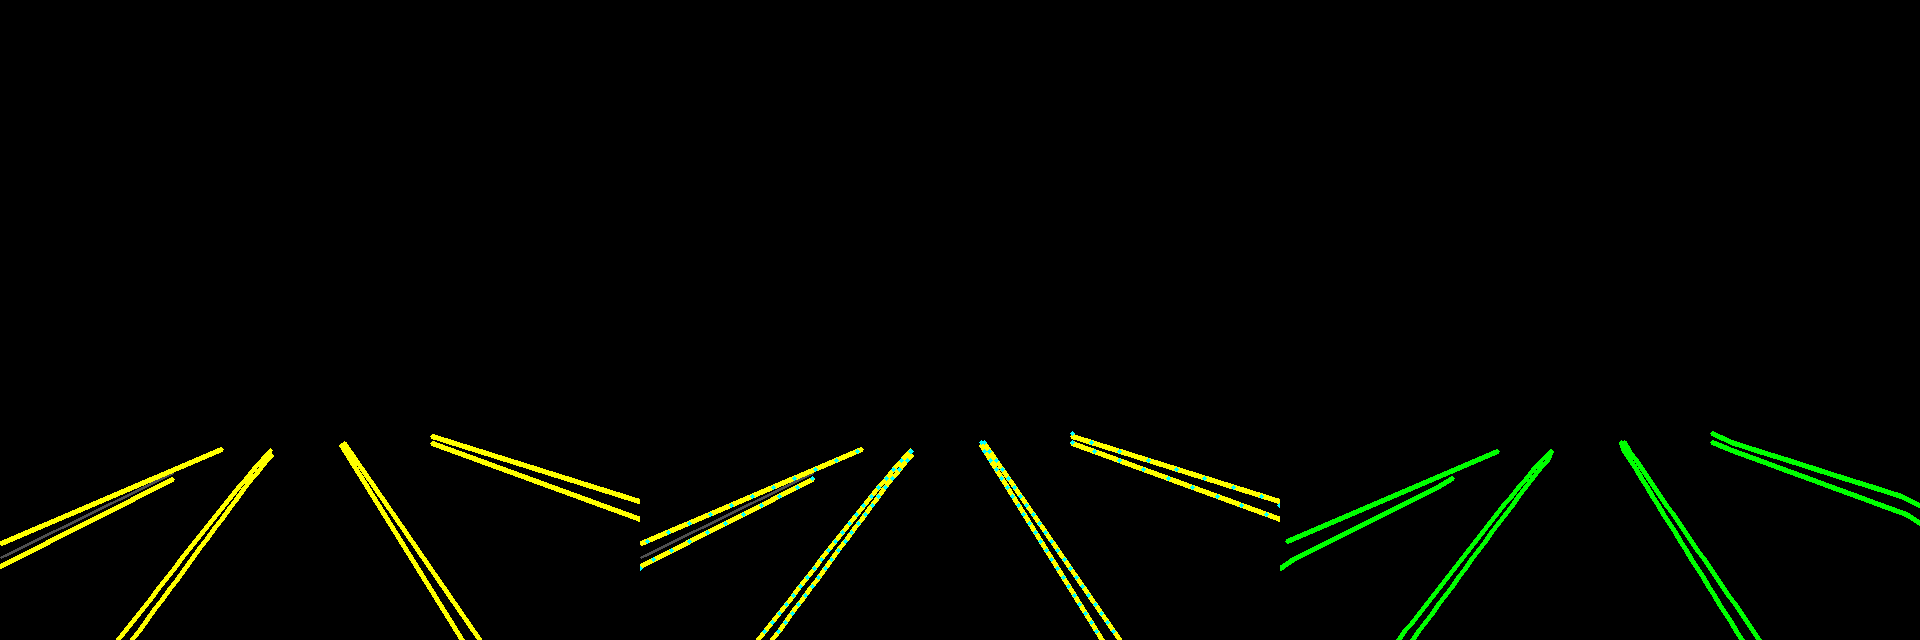

--- b605d5d8-a398208d_verify.png ---


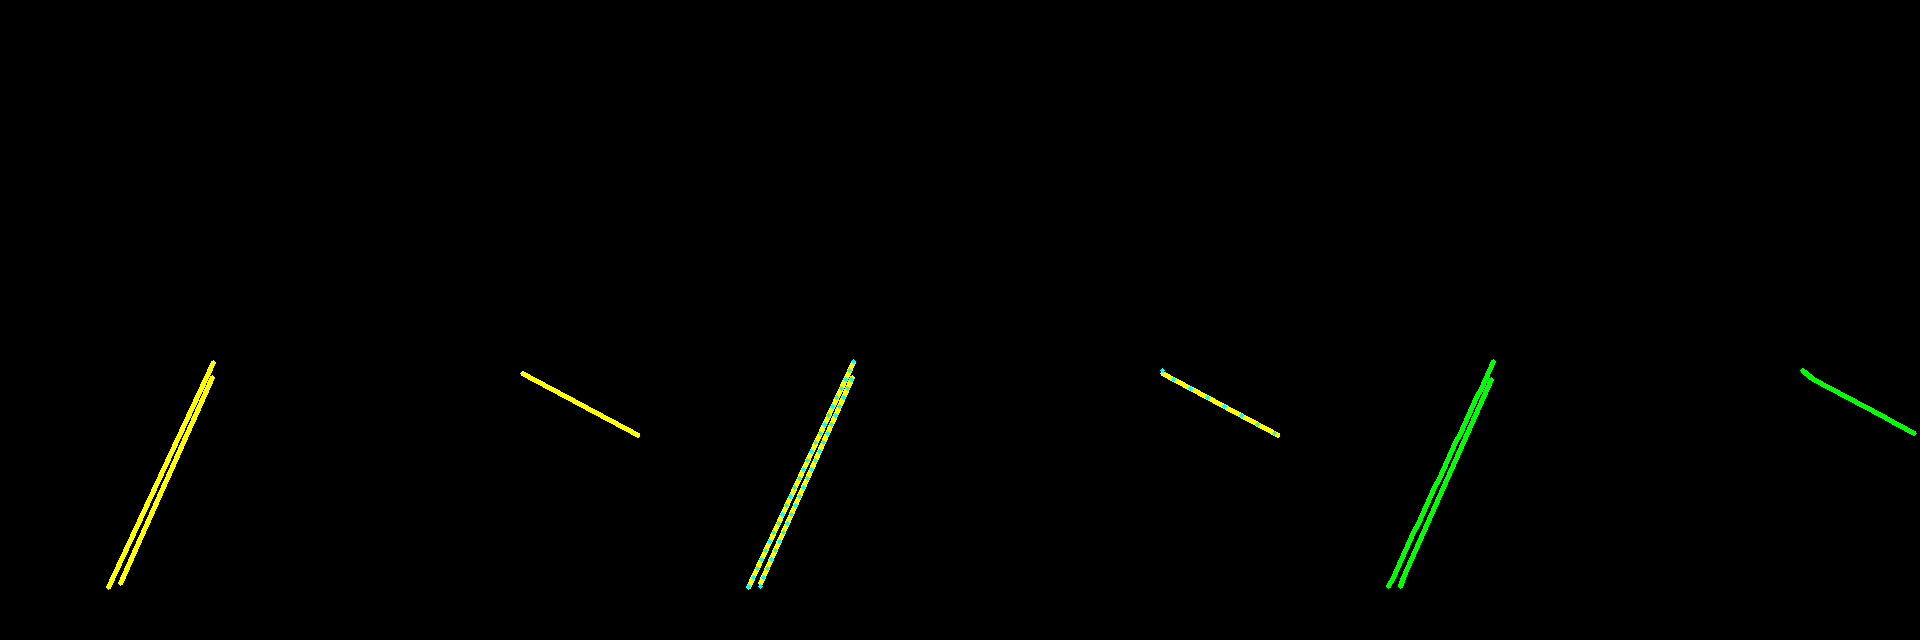

--- b7d277b3-26d83b90_verify.png ---


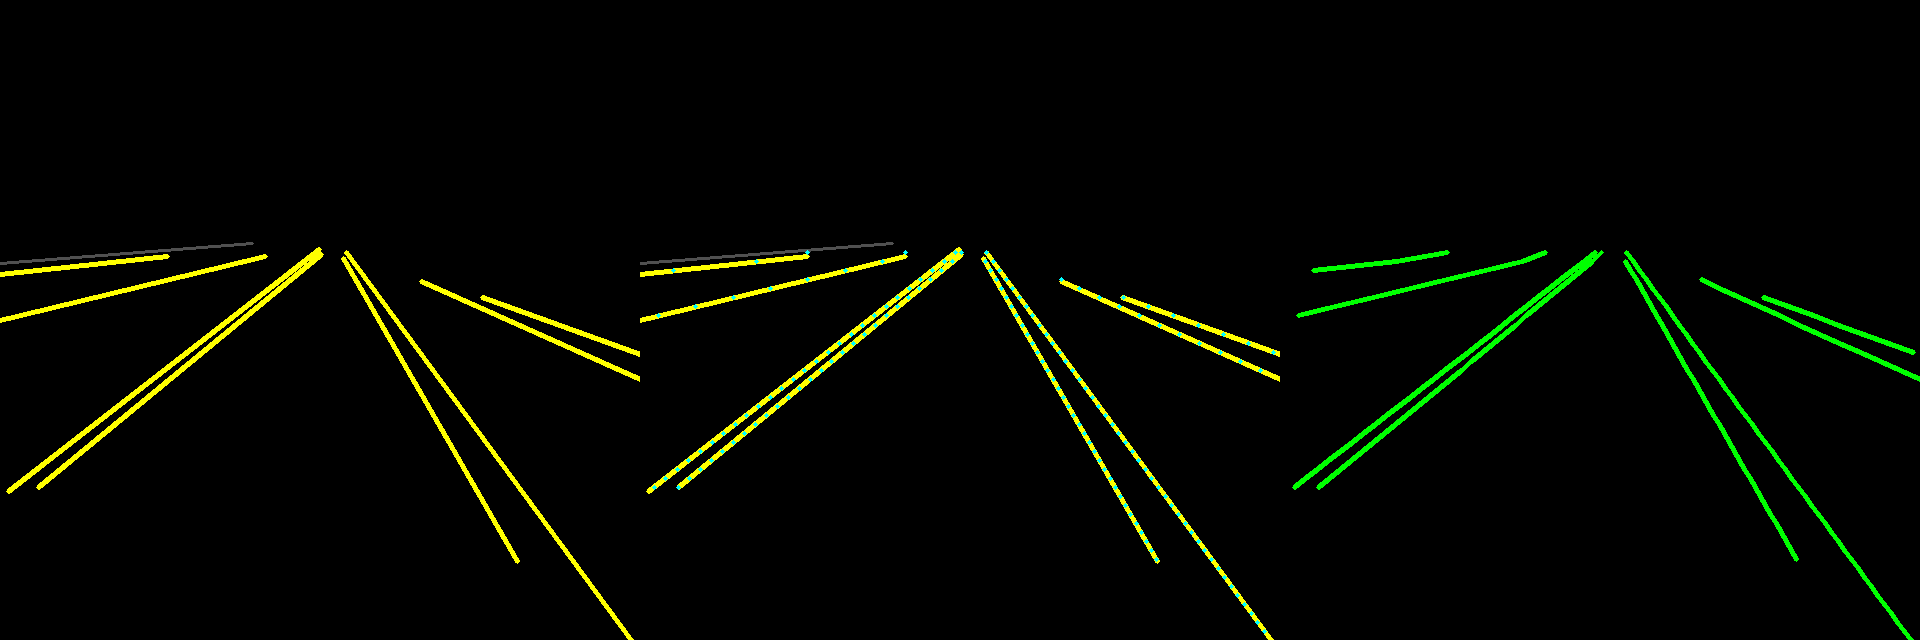

--- b93c2c35-9a03812d_verify.png ---


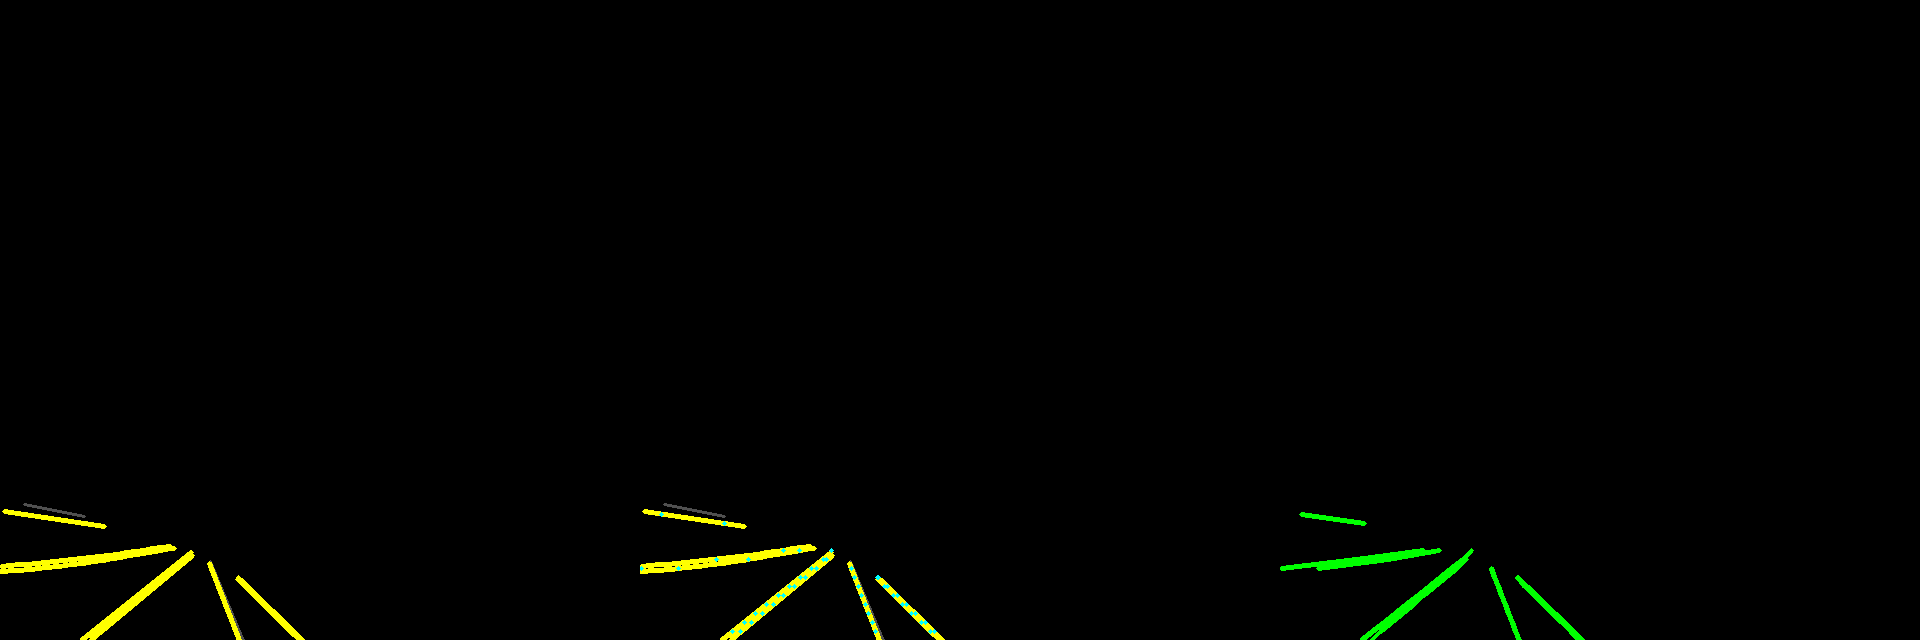

--- bc101f0f-6efce9bc_verify.png ---


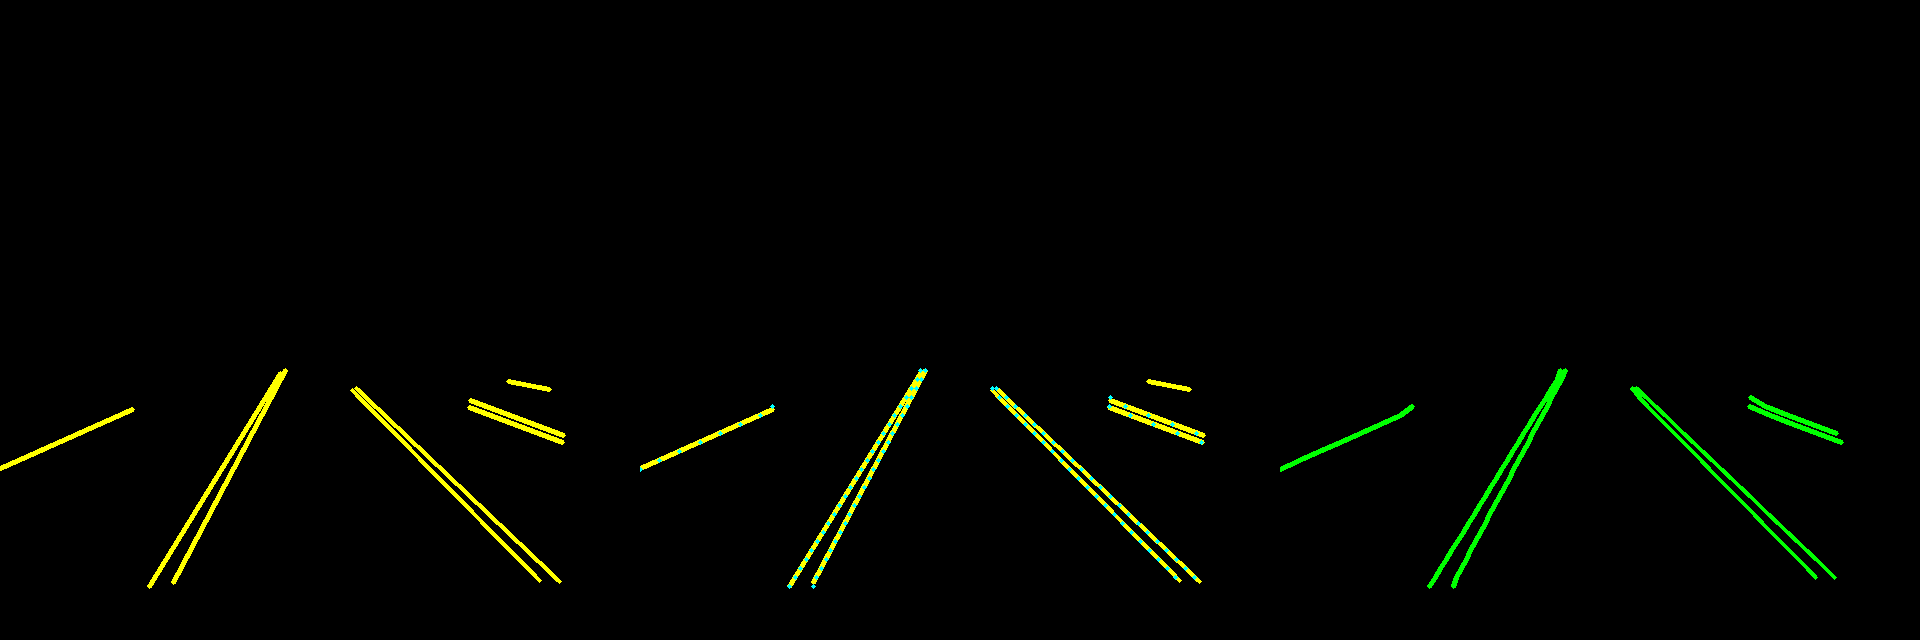

--- c53986c1-311f3693_verify.png ---


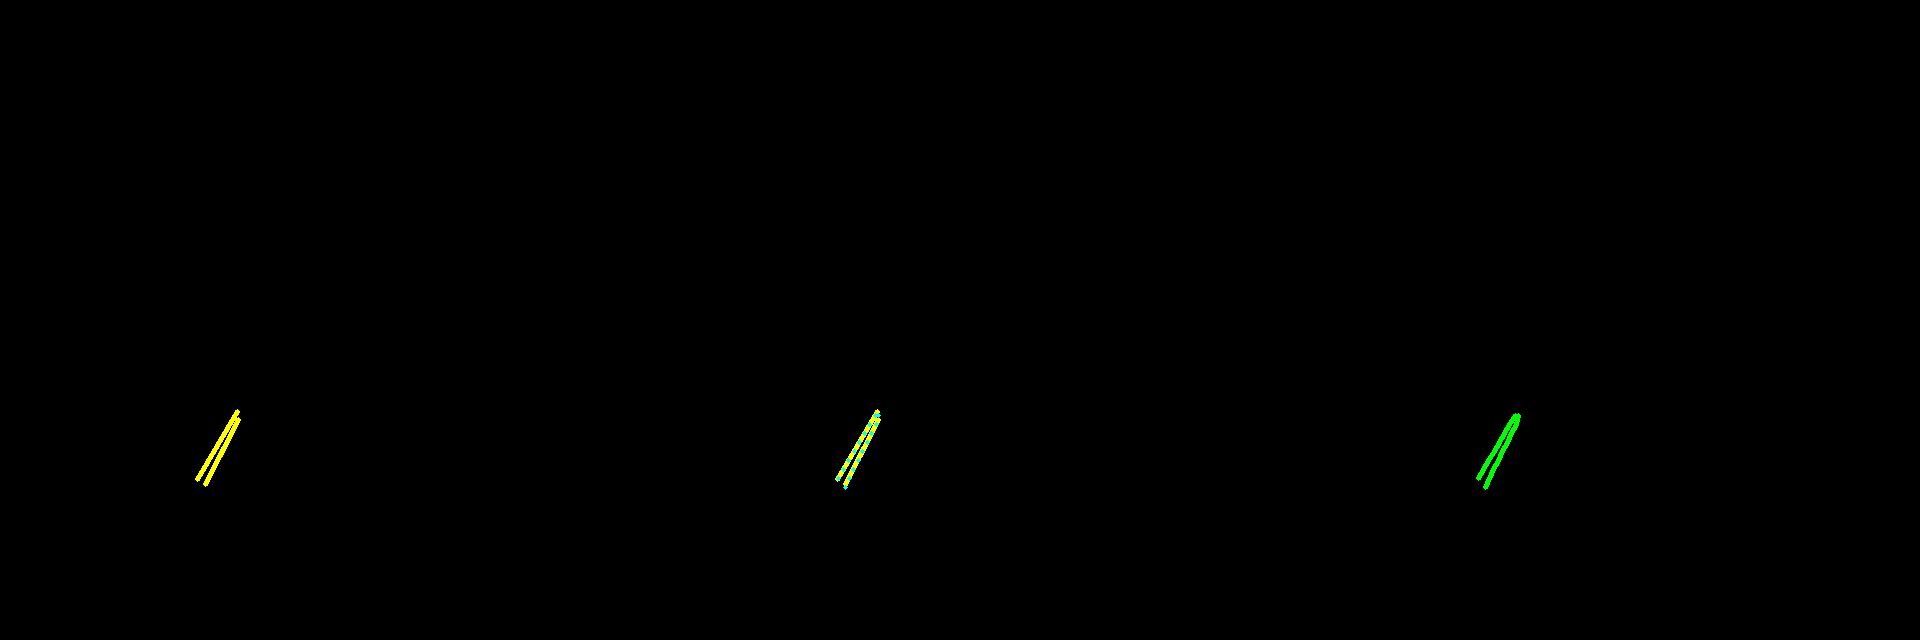

--- c53a24f2-5e6c5cbd_verify.png ---


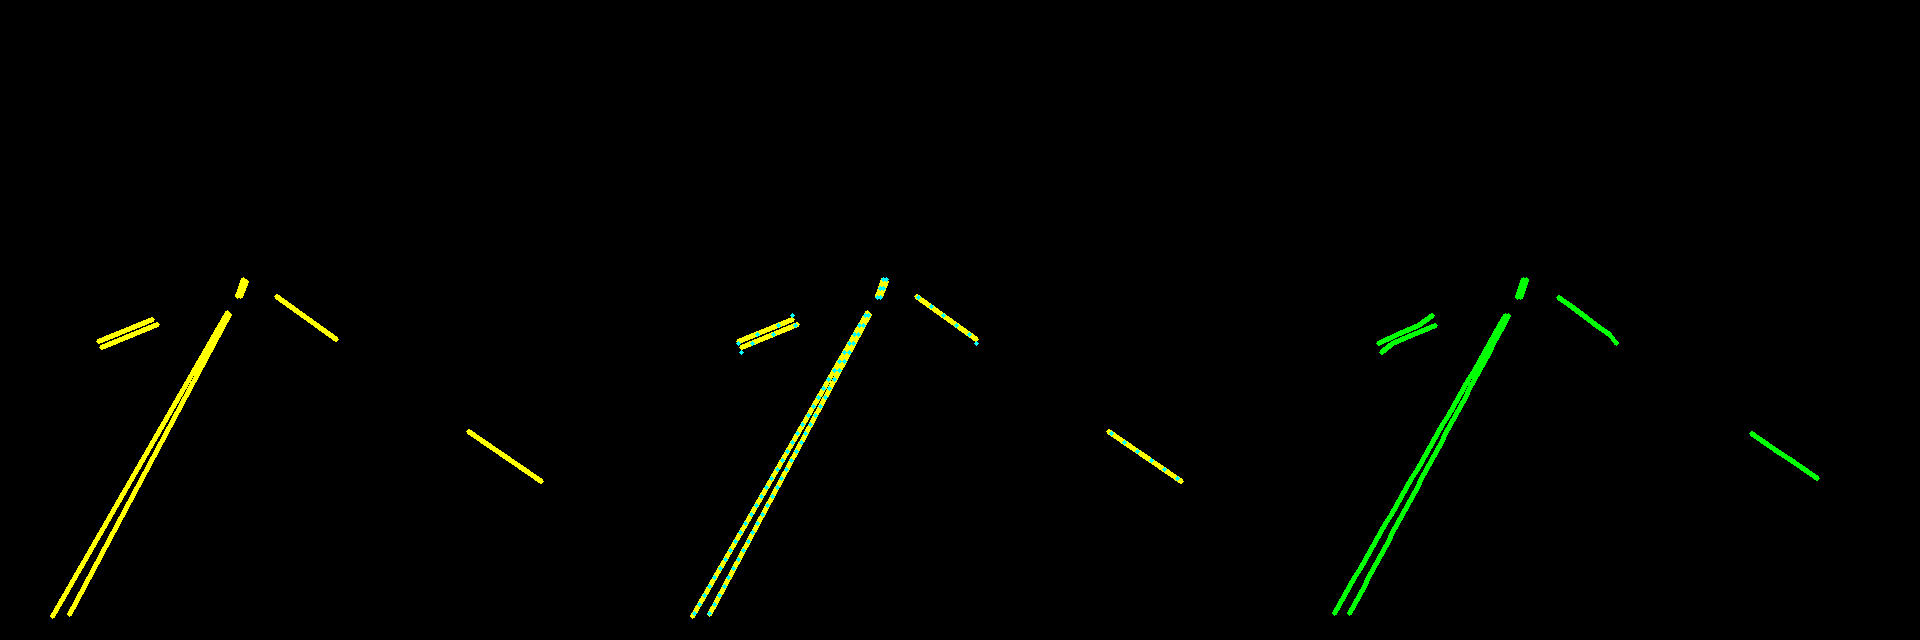

--- c63c27a4-6c1b3f4e_verify.png ---


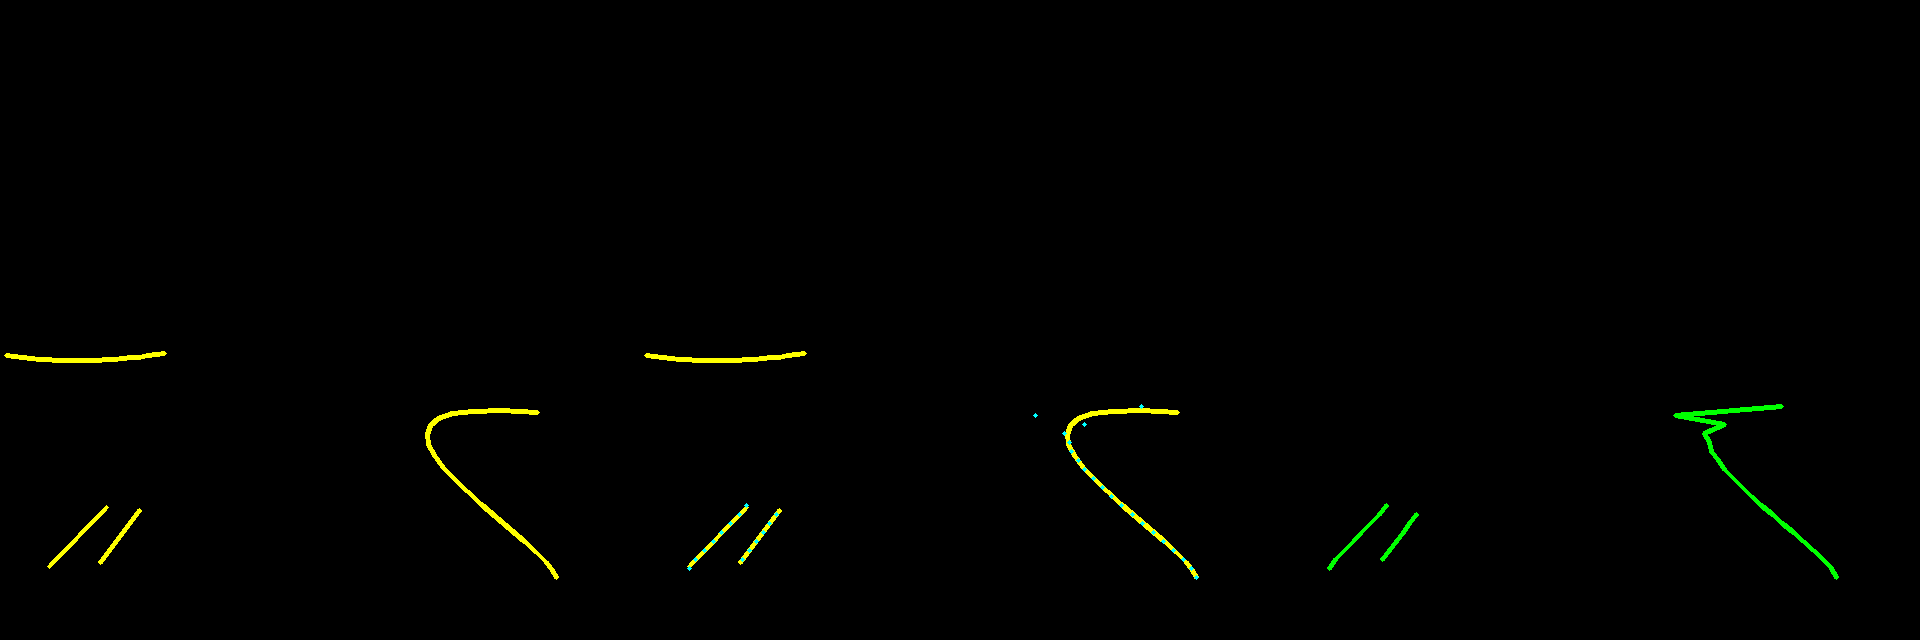

--- c8eeb9c9-d3212cfe_verify.png ---


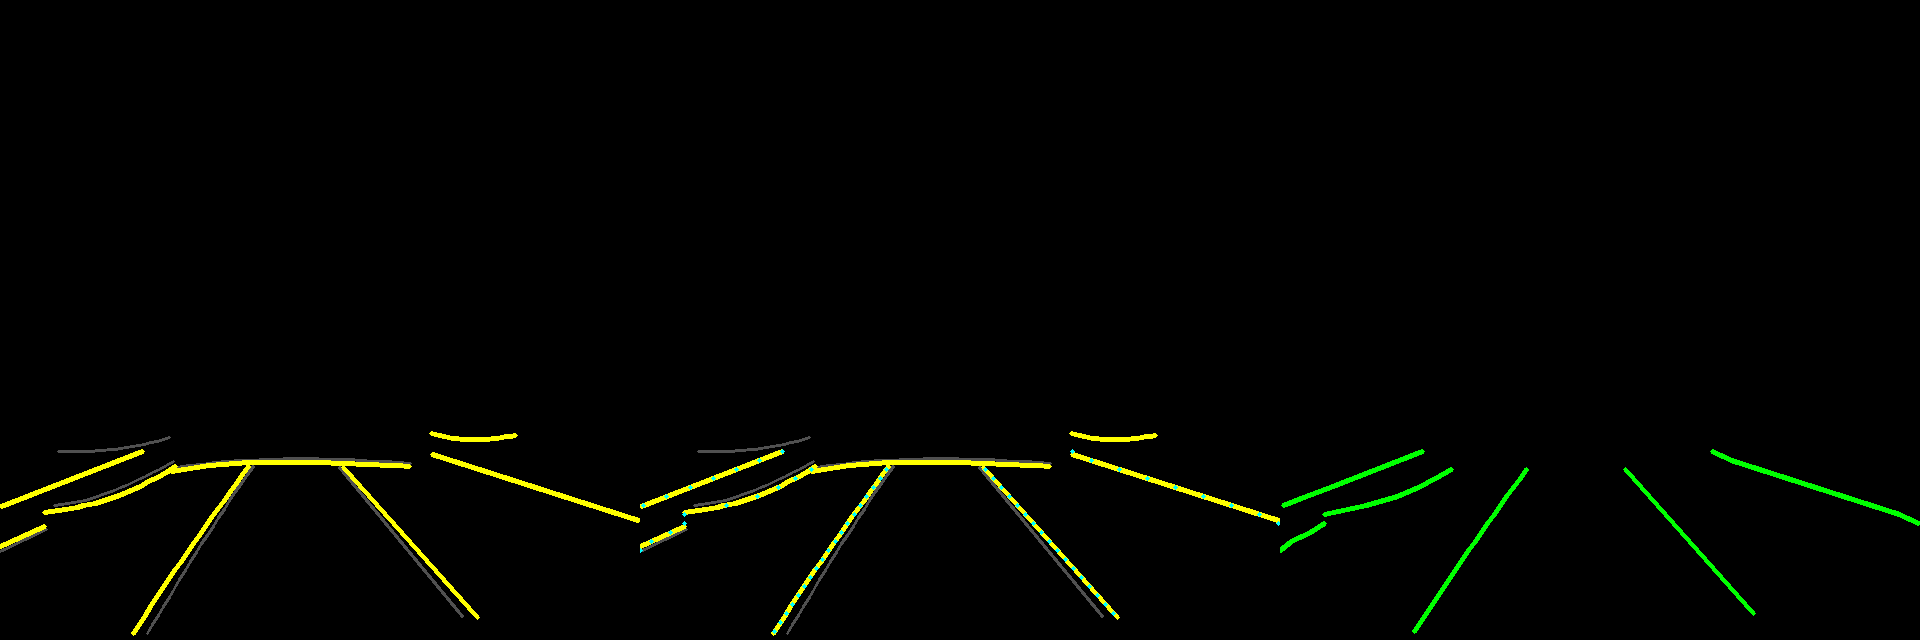

--- c9557697-363a490d_verify.png ---


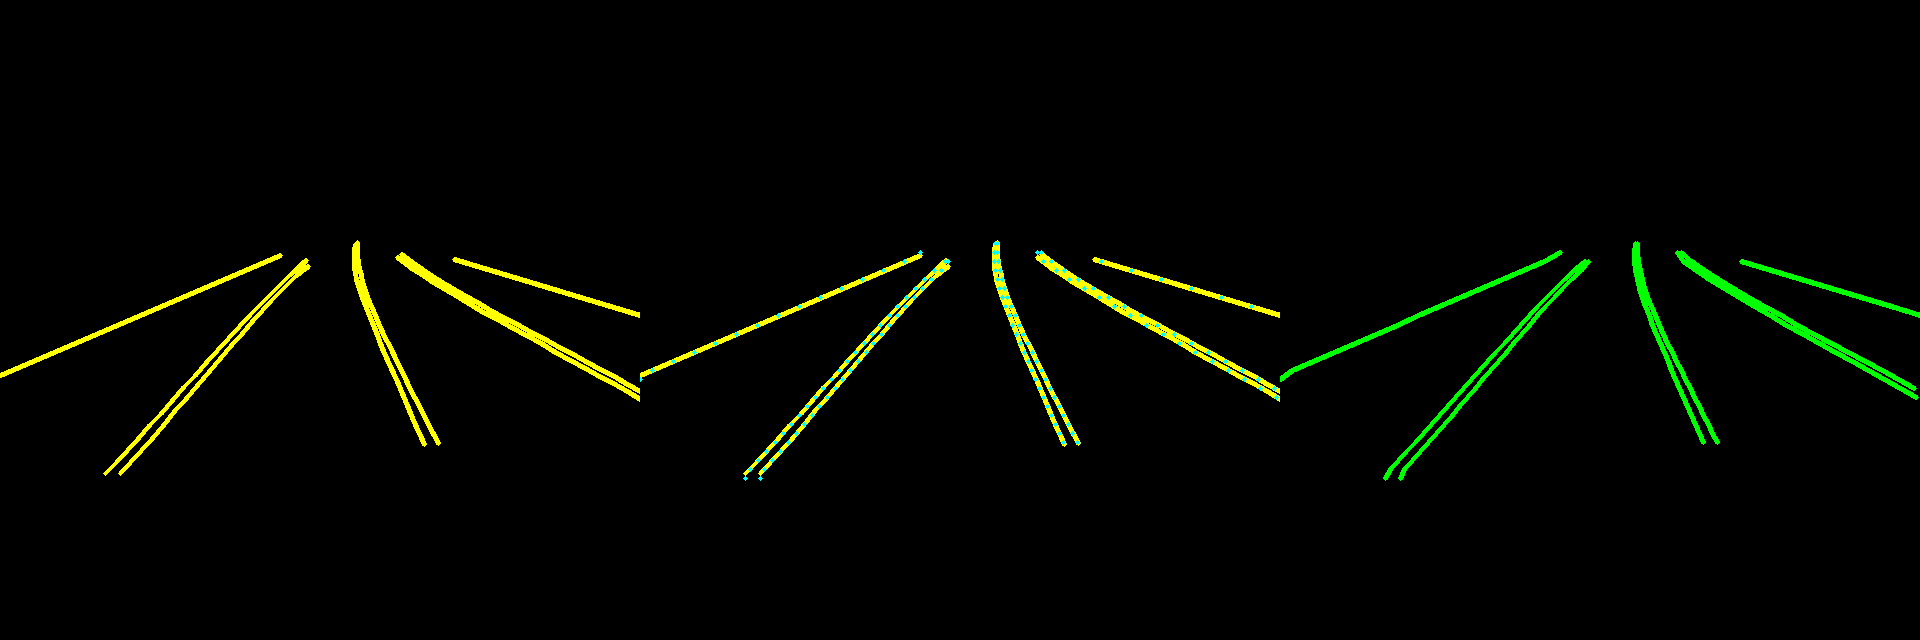

In [5]:
from pathlib import Path
from IPython.display import Image, display
panels = sorted(Path(VERIFY_OUT).glob('*_verify.png'))
print(f'Found {len(panels)} verification panels in {VERIFY_OUT}')
for p in panels[:10]:
    print(f'--- {p.name} ---')
    display(Image(str(p)))

### Cell 6: Batch-convert all BDD lane JSONs -> /content/lane_targets/
Writes `.pt` tensors LOCALLY to `/content/lane_targets/{train,val}/`.
(Drive can't handle ~80k small-file writes; we tarball in cell 8.)

Splits are renamed: BDD's `train` -> our `train2017`, BDD's `val` ->
`val2017`. This matches the RMT-PPAD dataset convention so the P6
dataloader doesn't need a name remap.

Each `.pt` = `(4, 78)` float32 tensor, ~1.3 KB. Expected wall time:
5-10 min for ~80k JSONs on standard Colab CPU.

In [6]:
import sys, os
LANE_TARGETS_LOCAL = '/content/lane_targets'
os.makedirs(LANE_TARGETS_LOCAL, exist_ok=True)

# MAX_LANES already set in cell 4. P5 loss and P7 NMS must match.
cmd = [sys.executable, '-u',
       'stage2/rmt_ppad_migration/P1_data_conversion/tools/convert_bdd_labels.py',
       '--train_input', str(LANE_TRAIN_SRC),
       '--val_input',   str(LANE_VAL_SRC),
       '--out_root',    LANE_TARGETS_LOCAL,
       '--train_out_name', 'train2017',
       '--val_out_name',   'val2017',
       '--img_h', '720', '--img_w', '1280',
       '--target_h', '640', '--target_w', '640',
       '--num_points', '72',
       '--max_lanes', str(MAX_LANES)]
log = os.path.join(LOG_DIR, 'NB80_convert_polyline.log')
rc = run_streaming(cmd, log_path=log, check=False)
if rc != 0:
    raise RuntimeError(f'convert_bdd_labels.py rc={rc}; see {log}')

[run_streaming] command: /usr/bin/python3 -u stage2/rmt_ppad_migration/P1_data_conversion/tools/convert_bdd_labels.py --train_input /content/bdd100k_labels/100k/train --val_input /content/bdd100k_labels/100k/val --out_root /content/lane_targets --train_out_name train2017 --val_out_name val2017 --img_h 720 --img_w 1280 --target_h 640 --target_w 640 --num_points 72 --max_lanes 8
[run_streaming] log file: /content/drive/MyDrive/EcoCAR/training_runs/notebook_logs/NB80_convert_polyline.log
Converting BDD labels from /content/bdd100k_labels/100k/train -> /content/lane_targets/train2017
  [5000] elapsed=17s  empty=336  failed=0  rate=288/s
  [10000] elapsed=33s  empty=698  failed=0  rate=305/s
  [15000] elapsed=48s  empty=1062  failed=0  rate=310/s
  [20000] elapsed=64s  empty=1452  failed=0  rate=311/s
  [25000] elapsed=80s  empty=1843  failed=0  rate=313/s
  [30000] elapsed=95s  empty=2207  failed=0  rate=314/s
  [35000] elapsed=111s  empty=2585  failed=0  rate=316/s
  [40000] elapsed=126s 

### Cell 7: Spot-check a converted tensor
Load one .pt at random and confirm shape/dtype/sentinels. Catches any
silent corruption before we ship the tarball to Drive.

In [7]:
import random, torch, json
from pathlib import Path

pts = sorted(Path(LANE_TARGETS_LOCAL).rglob('*.pt'))
print(f'Total .pt files: {len(pts)}')

random.seed(0)
for p in random.sample(pts, min(5, len(pts))):
    t = torch.load(p, weights_only=True)
    n_valid = int((t[:, 1] > 0.5).sum())
    print(f'  {p.name}: shape={tuple(t.shape)} dtype={t.dtype}  n_lanes_encoded={n_valid}')
    print(f'    row0: neg={float(t[0,0]):.2f} pos={float(t[0,1]):.2f} '
          f'start_y={float(t[0,2]):.3f} start_x={float(t[0,3]):.1f} '
          f'theta={float(t[0,4]):.3f} length={float(t[0,5]):.1f}')

summary_path = Path(LANE_TARGETS_LOCAL) / 'conversion_summary.json'
if summary_path.exists():
    print('\n=== conversion_summary.json ===')
    print(summary_path.read_text())

Total .pt files: 80000
  80c62ee8-b7c50f01.pt: shape=(8, 78) dtype=torch.float32  n_lanes_encoded=6
    row0: neg=0.00 pos=1.00 start_y=0.056 start_x=586.3 theta=0.730 length=21.0
  8c81bf19-18f8ffa7.pt: shape=(8, 78) dtype=torch.float32  n_lanes_encoded=4
    row0: neg=0.00 pos=1.00 start_y=0.296 start_x=0.0 theta=0.034 length=3.0
  0d96212e-cd0b8749.pt: shape=(8, 78) dtype=torch.float32  n_lanes_encoded=3
    row0: neg=0.00 pos=1.00 start_y=0.310 start_x=492.1 theta=0.957 length=4.0
  5681601b-87014916.pt: shape=(8, 78) dtype=torch.float32  n_lanes_encoded=7
    row0: neg=0.00 pos=1.00 start_y=0.254 start_x=560.9 theta=0.779 length=20.0
  aac2029c-0755b19d.pt: shape=(8, 78) dtype=torch.float32  n_lanes_encoded=3
    row0: neg=0.00 pos=1.00 start_y=0.155 start_x=638.2 theta=0.856 length=11.0

=== conversion_summary.json ===
{
  "train2017": {
    "total": 70000,
    "written": 70000,
    "empty": 5189,
    "failed": 0,
    "lanes_hist": [
      5189,
      5469,
      7492,
      6343

### Cell 8: Tarball + copy to Drive
One ~20 MB tarball is the right shape for Drive (one large file, not 10k
small ones). On future Colab sessions, P5/P6 will extract this back to
`/content/lane_targets/`.

In [8]:
import subprocess, os, shutil
from pathlib import Path

TAR_LOCAL = '/content/lane_targets_polyline.tar.gz'
TAR_DRIVE_DIR = '/content/drive/MyDrive/EcoCAR/datasets'
TAR_DRIVE = os.path.join(TAR_DRIVE_DIR, 'lane_targets_clr_v1_polyline.tar.gz')
os.makedirs(TAR_DRIVE_DIR, exist_ok=True)

print(f'[tar] /content/lane_targets/ -> {TAR_LOCAL}')
subprocess.check_call(['tar', '-C', '/content', '-czf', TAR_LOCAL, 'lane_targets'])
sz = os.path.getsize(TAR_LOCAL) / 1e6
print(f'  size: {sz:.1f} MB')

print(f'[copy] {TAR_LOCAL} -> {TAR_DRIVE}')
shutil.copy2(TAR_LOCAL, TAR_DRIVE)
print(f'  done; tarball persisted at {TAR_DRIVE}')

RESULTS_DIR = Path('/content/drive/MyDrive/EcoCAR/yolop_vehicle_lane/'
                   'stage2/rmt_ppad_migration/P1_data_conversion/results')
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
summary_src = Path(LANE_TARGETS_LOCAL) / 'conversion_summary.json'
if summary_src.exists():
    shutil.copy2(summary_src, RESULTS_DIR / 'conversion_summary_polyline.json')
    print(f'[copy] conversion_summary_polyline.json -> {RESULTS_DIR}')

[tar] /content/lane_targets/ -> /content/lane_targets_polyline.tar.gz
  size: 39.2 MB
[copy] /content/lane_targets_polyline.tar.gz -> /content/drive/MyDrive/EcoCAR/datasets/lane_targets_clr_v1_polyline.tar.gz
  done; tarball persisted at /content/drive/MyDrive/EcoCAR/datasets/lane_targets_clr_v1_polyline.tar.gz
[copy] conversion_summary_polyline.json -> /content/drive/MyDrive/EcoCAR/yolop_vehicle_lane/stage2/rmt_ppad_migration/P1_data_conversion/results


### Cell 9: P1 acceptance test
Asserts the two acceptance criteria from the migration plan:
1. verify_conversion produced 10 panels and all flagged OK in the log
2. lane_targets has one .pt per source mask, in both splits

In [9]:
from pathlib import Path
import json

def _count_source_records(src):
    """Records can come from a consolidated JSON (array) or a per-image dir."""
    src = Path(src)
    if src.is_file():
        with open(src, 'r', encoding='utf-8') as f:
            data = json.load(f)
        return len(data) if isinstance(data, list) else 1
    if src.is_dir():
        return sum(1 for _ in src.glob('*.json'))
    return 0

checks = []
panels = sorted(Path(VERIFY_OUT).glob('*_verify.png'))
checks.append(('>=10 verification panels', len(panels) >= 10, f'{len(panels)} panels'))

print('[acceptance] counting source records...')
n_train_records = _count_source_records(LANE_TRAIN_SRC)
n_val_records   = _count_source_records(LANE_VAL_SRC)
print(f'  train records: {n_train_records}')
print(f'  val records:   {n_val_records}')

for out_split, n_records in (('train2017', n_train_records), ('val2017', n_val_records)):
    n_pt = sum(1 for _ in (Path(LANE_TARGETS_LOCAL) / out_split).glob('*.pt'))
    checks.append((f'one .pt per source record ({out_split})', n_pt == n_records,
                   f'{n_pt} .pt vs {n_records} records'))

summary_path = Path(LANE_TARGETS_LOCAL) / 'conversion_summary.json'
if summary_path.exists():
    s = json.loads(summary_path.read_text())
    # Empty fraction tolerance: BDD has many frames with no painted lane
    # lines (night, parking lots, intersections with only crosswalks).
    # After the loader fix, those records yield empty .pt placeholders -
    # expect ~7-10% empty. Much above 15% and our filters are wrong.
    for split, info in s.items():
        empty_frac = info['empty'] / max(1, info['total'])
        checks.append((f'<15% empty records ({split})',
                       empty_frac < 0.15,
                       f'{info["empty"]} / {info["total"]} empty ({empty_frac*100:.1f}%)'))

fails = 0
print('\n[P1 acceptance]')
for label, ok, detail in checks:
    tag = 'OK' if ok else 'X '
    print(f'  {tag}  {label:40s}  {detail}')
    if not ok:
        fails += 1
print('\n[P1 result]', 'PASS' if fails == 0 else f'FAIL ({fails} check(s) not OK)')

[acceptance] counting source records...
  train records: 70000
  val records:   10000

[P1 acceptance]
  OK  >=10 verification panels                  10 panels
  OK  one .pt per source record (train2017)     70000 .pt vs 70000 records
  OK  one .pt per source record (val2017)       10000 .pt vs 10000 records
  OK  <15% empty records (train2017)            5189 / 70000 empty (7.4%)
  OK  <15% empty records (val2017)              718 / 10000 empty (7.2%)

[P1 result] PASS
